1. Persiapan API Kaggle dan eksraksi dataset

In [ ]:
# 1. Instalasi pustaka yang dibutuhkan
!pip install -q kaggle transformers datasets evaluate

# 2. Upload kredensial Kaggle secara interaktif
import os
import shutil
from google.colab import files

print("SILAKAN UNGGAH FILE 'kaggle.json'")
uploaded = files.upload()

# 3. Konfigurasi direktori Kaggle
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

# Memeriksa dan memindahkan file yang baru saja diunggah
if 'kaggle.json' in uploaded:
    shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 600)
    print("Kredensial Kaggle berhasil dikonfigurasi.")
else:
    print("ERROR: Anda belum mengunggah file kaggle.json!")

# 4. Mengunduh dataset Amazon Books Reviews dari Kaggle
print("\nMengunduh dataset dari Kaggle...")
!kaggle datasets download -d mohamedbakhet/amazon-books-reviews

# 5. Mengekstrak file zip
import zipfile
print("Mengekstrak dataset...")
with zipfile.ZipFile("amazon-books-reviews.zip", 'r') as zip_ref:
    zip_ref.extractall("amazon_data")
    print("Dataset berhasil diekstrak ke folder 'amazon_data'.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
SILAKAN UNGGAH FILE 'kaggle.json'


Saving kaggle.json to kaggle.json
Kredensial Kaggle berhasil dikonfigurasi.

Mengunduh dataset dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews
License(s): CC0-1.0
100% 1.06G/1.06G [00:30<00:00, 36.8MB/s]

Mengekstrak dataset...
Dataset berhasil diekstrak ke folder 'amazon_data'.


2. Exploratory Data Analysis (EDA) dan Pembersihan Data

Sel ini menampilkan tabel data yang masih mentah, melakukan rekayasa fitur menjadi klasifikasi biner, menampilkan tabel data bersih, serta memvisualisasikan distribusinya

Memuat dataset ulasan buku...
1. EDA: TABEL DATA MENTAH (SEBELUM PEMBERSIHAN)
Total baris data awal: 3,000,000


,Id,Title,review/helpfulness,review/text
0,1882931173,Its Only Art If Its Well Hung!,7/7,This is only for Julie Strain fans. It's a col...
1,0826414346,Dr. Seuss: American Icon,10/10,I don't care much for Dr. Seuss but after read...
2,0826414346,Dr. Seuss: American Icon,10/11,"If people become the books they read and if ""t..."
3,0826414346,Dr. Seuss: American Icon,7/7,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,0826414346,Dr. Seuss: American Icon,3/3,Philip Nel - Dr. Seuss: American IconThis is b...


2. EDA: TABEL DATA BERSIH (KLASIFIKASI BINER)
Total baris data valid setelah filter: 989,781


,review/helpfulness,HelpfulnessRatio,Label,Word_Count,review/text
0,7/7,1.000000,1,86,This is only for Julie Strain fans. It's a col...
1,10/10,1.000000,1,252,I don't care much for Dr. Seuss but after read...
2,10/11,0.909091,1,310,"If people become the books they read and if ""t..."
3,7/7,1.000000,1,560,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
9,3/5,0.600000,0,243,"As far as I am aware, this is the first book-l..."


/tmp/ipykernel_6268/1793978276.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, x='Label', palette='viridis')


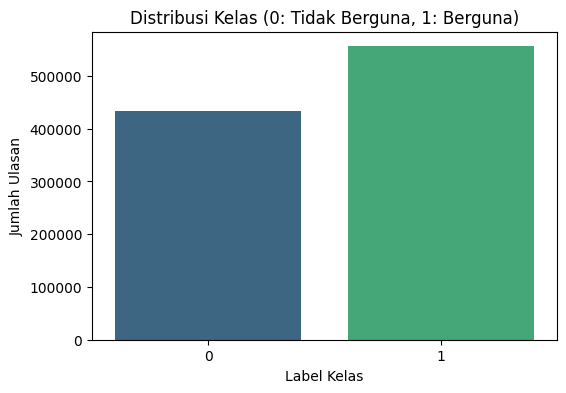

3. STATUS PEMBAGIAN DATA (TRAIN/TEST SPLIT)
Total Data Latih (X_train) : 12,000
Total Data Uji (X_test)    : 3,000
Komposisi Kelas Latih : Kelas 0 = 5234, Kelas 1 = 6766


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from IPython.display import display

# 1. Memuat dataset ulasan
print("Memuat dataset ulasan buku...")
df_raw = pd.read_csv('amazon_data/Books_rating.csv')


print("1. EDA: TABEL DATA MENTAH (SEBELUM PEMBERSIHAN)")
print(f"Total baris data awal: {len(df_raw):,}")
display(df_raw[['Id', 'Title', 'review/helpfulness', 'review/text']].head())


# 2. PROSES PEMBERSIHAN DATA & FEATURE ENGINEERING

# Membuang nilai kosong (NaN) pada teks ulasan dan label
df_clean = df_raw.dropna(subset=['review/text', 'review/helpfulness']).copy()

# Mengekstrak rasio dari format string (contoh: "15/16" -> Num=15.0, Denom=16.0)
df_clean[['HelpfulNum', 'HelpfulDenom']] = df_clean['review/helpfulness'].str.split('/', n=1, expand=True).astype(float)

# Memfilter data: Hanya ambil ulasan dengan minimal 5 interaksi untuk validitas komunal
df_filtered = df_clean[df_clean['HelpfulDenom'] >= 5].copy()

# Kalkulasi Rasio Kontinu
df_filtered['HelpfulnessRatio'] = df_filtered['HelpfulNum'] / df_filtered['HelpfulDenom']

# TRANSFORMASI BINER (Threshold 0.75)
# Kelas 1 (Berguna) jika rasio >= 0.75. Kelas 0 (Tidak Berguna) jika < 0.75
threshold = 0.75
df_filtered['Label'] = (df_filtered['HelpfulnessRatio'] >= threshold).astype(int)

# Menghitung panjang kata untuk analisis kompleksitas bacaan
df_filtered['Word_Count'] = df_filtered['review/text'].apply(lambda x: len(str(x).split()))

print("2. EDA: TABEL DATA BERSIH (KLASIFIKASI BINER)")
print(f"Total baris data valid setelah filter: {len(df_filtered):,}")
display(df_filtered[['review/helpfulness', 'HelpfulnessRatio', 'Label', 'Word_Count', 'review/text']].head())

# 3. VISUALISASI DISTRIBUSI KELAS & PEMBAGIAN DATA

plt.figure(figsize=(6, 4))
sns.countplot(data=df_filtered, x='Label', palette='viridis')
plt.title('Distribusi Kelas (0: Tidak Berguna, 1: Berguna)')
plt.ylabel('Jumlah Ulasan')
plt.xlabel('Label Kelas')
plt.show()

# Sub-sampling data secara proporsional untuk efisiensi RAM GPU (15.000 sampel)
df_sample = df_filtered.sample(n=15000, random_state=42)

# Pemisahan Fitur Latih dan Target
X = df_sample['review/text'].values
y = df_sample['Label'].values

# Split Data (80% Latih, 20% Uji) menggunakan stratify agar komposisi kelas seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("3. STATUS PEMBAGIAN DATA (TRAIN/TEST SPLIT)")
print(f"Total Data Latih (X_train) : {len(X_train):,}")
print(f"Total Data Uji (X_test)    : {len(X_test):,}")
print(f"Komposisi Kelas Latih : Kelas 0 = {np.sum(y_train==0)}, Kelas 1 = {np.sum(y_train==1)}")

3. Arsitektur Baseline (Bi-LSTM)


Melatih jaringan sekuensial rekuren dengan menggunakan binary_crossentropy


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. Tokenisasi dan Padding
max_vocab = 20000
max_length = 150 # Maksimal 150 kata per ulasan

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_length, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_length, padding='post', truncating='post')

# 2. Membangun Jaringan Bi-LSTM
model_bilstm = Sequential([
    Embedding(input_dim=max_vocab, output_dim=128, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Aktivasi probabilitas kelas 1
])

model_bilstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 3. Proses Pelatihan (Maksimal 10 Epoch, Patience 5)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Memulai pelatihan model Bi-LSTM...")
history_lstm = model_bilstm.fit(
    X_train_seq, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

# 4. Prediksi (Threshold 0.5 untuk penentuan tebakan kelas final)
y_pred_prob_lstm = model_bilstm.predict(X_test_seq)
y_pred_lstm = (y_pred_prob_lstm >= 0.5).astype(int).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Memulai pelatihan model Bi-LSTM...
Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.6290 - loss: 0.6454 - val_accuracy: 0.6708 - val_loss: 0.6395
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7656 - loss: 0.5005 - val_accuracy: 0.6825 - val_loss: 0.6130
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8860 - loss: 0.2893 - val_accuracy: 0.6533 - val_loss: 0.8429
Epoch 4/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9484 - loss: 0.1485 - val_accuracy: 0.6500 - val_loss: 1.3965
Epoch 5/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9758 - loss: 0.0781 - val_accuracy: 0.6258 - val_loss: 1.6589
Epoch 6/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9825 - loss: 0.0548 - val_accuracy: 0.6392 - val_loss: 1.9293
Epoch 7/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9868 - loss: 0.0408 - val_accuracy: 0.6425 - val_loss: 2.0799
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


4. Arsitektur Usulan SOTA (RoBERTa)

Inisialisasi Transfer Learning dari Hugging Face untuk mengeksekusi komputasi paralel Self-Attention

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset

# 1. Memuat Tokenizer RoBERTa
tokenizer_roberta = AutoTokenizer.from_pretrained("roberta-base")

# 2. Konversi Array ke format Hugging Face Dataset
train_dataset = Dataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})
test_dataset = Dataset.from_dict({"text": X_test.tolist(), "label": y_test.tolist()})

# 3. Fungsi Pemrosesan Paralel
def tokenize_function(examples):
    return tokenizer_roberta(examples["text"], padding="max_length", truncation=True, max_length=150)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# 4. Inisialisasi Model dengan 2 Label Klasifikasi Biner
model_roberta = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

# 5. Parameter Komputasi (DISELARASKAN AGAR APPLE-TO-APPLE)
training_args = TrainingArguments(
    output_dir="./roberta_results",
    eval_strategy="epoch",
    save_strategy="epoch",          # Wajib sama dengan eval_strategy jika pakai early stopping
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,            # PERBAIKAN: Plafon maksimal disamakan 10 epoch
    weight_decay=0.01,
    load_best_model_at_end=True,    # PERBAIKAN: Setara dengan restore_best_weights=True
    metric_for_best_model="eval_loss", # PERBAIKAN: Memantau Validation Loss
    greater_is_better=False         # PERBAIKAN: Karena memantau Loss, nilai makin kecil makin baik
)

# 6. Komputasi Model Transformer (DENGAN EARLY STOPPING)
trainer = Trainer(
    model=model_roberta,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)] # PERBAIKAN: Kesabaran sama-sama 5 epoch
)

print("Memulai pelatihan model RoBERTa dengan parameter setara...")
trainer.train()

# 7. Eksekusi Inferensi Prediksi
predictions = trainer.predict(test_dataset)
# Menggunakan Argmax untuk mengambil indeks logit kelas tertinggi (0 atau 1)
y_pred_roberta = np.argmax(predictions.predictions, axis=-1)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Memulai pelatihan model RoBERTa dengan parameter setara...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

5. Evaluasi komprehensif dan visualisasi confusion matrix

dengan mencetak metrik presisi klasifikasi secara lengkap (Akurasi, Presisi, Recall, F1-Score) dan menrender grafik Confusion Matrix



METRIK EVALUASI: Bi-LSTM (Baseline)
Accuracy  : 0.6750
Precision : 0.6721
Recall    : 0.8267
F1-Score  : 0.7414


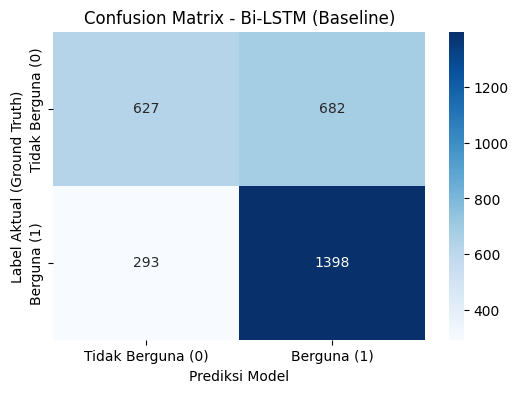


METRIK EVALUASI: RoBERTa (Proposed SOTA)
Accuracy  : 0.7507
Precision : 0.7586
Recall    : 0.8179
F1-Score  : 0.7871


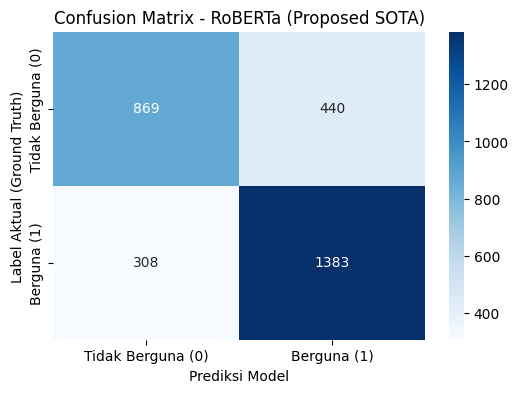

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, model_name):
    print(f"\n{'='*50}")
    print(f"METRIK EVALUASI: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")

    # Render grafik Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak Berguna (0)', 'Berguna (1)'],
                yticklabels=['Tidak Berguna (0)', 'Berguna (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Label Aktual (Ground Truth)')
    plt.xlabel('Prediksi Model')
    plt.show()

# Evaluasi Bi-LSTM (Baseline)
evaluate_and_plot(y_test, y_pred_lstm, "Bi-LSTM (Baseline)")

# Evaluasi RoBERTa (Proposed SOTA)
evaluate_and_plot(y_test, y_pred_roberta, "RoBERTa (Proposed SOTA)")

Visualisasi

Gambar 3.1 Grafik evaluasi Binary Cross-Entropy pada proses pelatihan model Bi-LSTM

Gambar 3.2 Grafik metrik Training Loss pada setiap step model RoBERTa

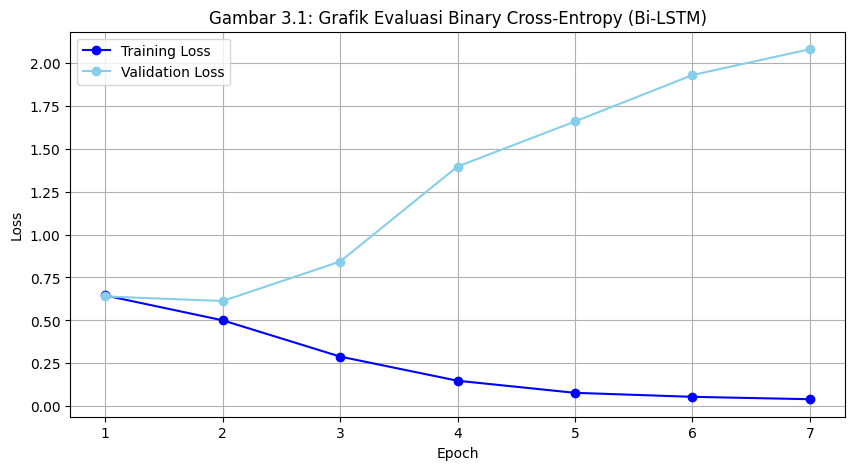

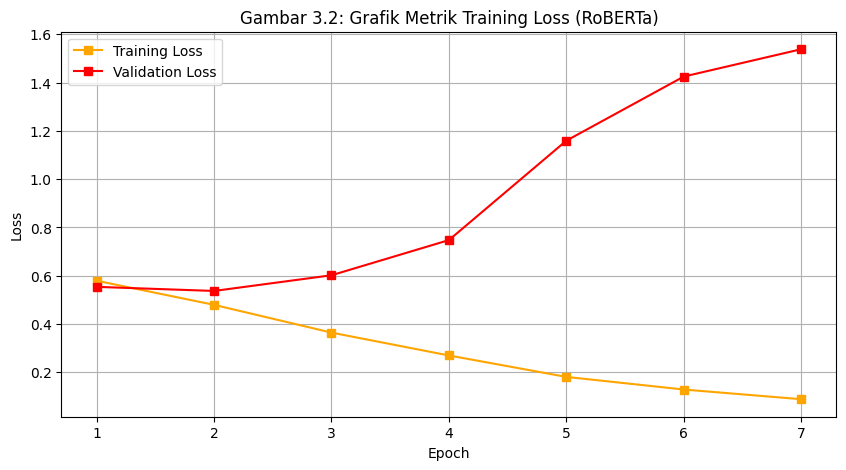

In [ ]:
import matplotlib.pyplot as plt

# Data log yang diberikan pengguna
bilstm_epochs = [1, 2, 3, 4, 5, 6, 7]
bilstm_train_loss = [0.6454, 0.5005, 0.2893, 0.1485, 0.0781, 0.0548, 0.0408]
bilstm_val_loss = [0.6395, 0.6130, 0.8429, 1.3965, 1.6589, 1.9293, 2.0799]

roberta_epochs = [1, 2, 3, 4, 5, 6, 7]
roberta_train_loss = [0.579521, 0.479563, 0.364536, 0.269863, 0.181065, 0.128747, 0.088586]
roberta_val_loss = [0.554064, 0.537119, 0.602118, 0.747834, 1.159623, 1.425246, 1.538548]

# --- Gambar 3.1: Grafik evaluasi Binary Cross-Entropy Bi-LSTM ---
plt.figure(figsize=(10, 5))
plt.plot(bilstm_epochs, bilstm_train_loss, label='Training Loss', marker='o', color='blue')
plt.plot(bilstm_epochs, bilstm_val_loss, label='Validation Loss', marker='o', color='skyblue')
plt.title('Gambar 3.1: Grafik Evaluasi Binary Cross-Entropy (Bi-LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Gambar 3.2: Grafik metrik Training Loss RoBERTa ---
plt.figure(figsize=(10, 5))
plt.plot(roberta_epochs, roberta_train_loss, label='Training Loss', color='orange', marker='s')
plt.plot(roberta_epochs, roberta_val_loss, label='Validation Loss', color='red', marker='s')
plt.title('Gambar 3.2: Grafik Metrik Training Loss (RoBERTa)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Berdasarkan grafik Gambar 3.1 dan Gambar 3.2, berikut adalah penjelasan hasilnya:

1. Gejala Overfitting: Pada kedua model (Bi-LSTM dan RoBERTa), kita melihat fenomena overfitting yang jelas. Training Loss (garis biru/oranye) terus menurun hingga epoch 7, menunjukkan model semakin ahli mengenali data latih. Namun, Validation Loss (garis muda/merah) mulai meningkat tajam setelah epoch ke-2.

2. Titik Optimal (Sweet Spot): Model mencapai performa terbaiknya di sekitar Epoch 2. Setelah titik itu, performa pada data validasi memburuk. Inilah alasan mengapa kita menggunakan Early Stopping untuk mengambil bobot model dari epoch ke-2, bukan epoch ke-7.

3. Perbandingan Stabilitas:

- Bi-LSTM: Lonjakan Validation Loss-nya sangat ekstrem (mencapai angka > 2.0), menunjukkan ketidakstabilan model dalam menangani data baru setelah terlalu lama dilatih.
- RoBERTa: Meskipun juga mengalami overfitting, kenaikan loss-nya sedikit lebih terkendali dibandingkan Bi-LSTM, yang menunjukkan arsitektur Transformer memiliki regulasi internal yang sedikit lebih baik daripada LSTM tradisional dalam skenario ini.


Kesimpulannya, meskipun pelatihan dilanjutkan sampai 7 epoch, model yang paling layak digunakan untuk produksi adalah model hasil simpanan dari epoch ke-2.

Tabel 3.1 Komparasi Metrik Performa Klasifikasi (Unseen Data)


,Parameter Evaluasi,Bi-LSTM (Baseline),RoBERTa (Proposed)
0,Accuracy,0.6750,0.7507
1,Precision,0.6721,0.7586
2,Recall,0.8267,0.8179
3,F1-Score,0.7414,0.7871


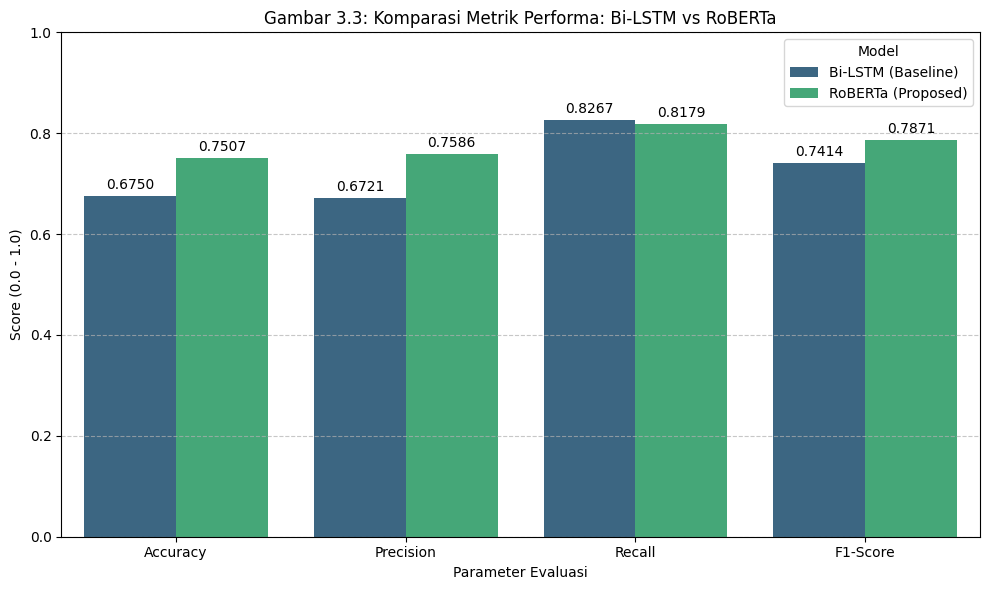

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menyiapkan data untuk tabel
data = {
    'Parameter Evaluasi': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Bi-LSTM (Baseline)': [0.6750, 0.6721, 0.8267, 0.7414],
    'RoBERTa (Proposed)': [0.7507, 0.7586, 0.8179, 0.7871]
}

df_metrics = pd.DataFrame(data)
print("Tabel 3.1 Komparasi Metrik Performa Klasifikasi (Unseen Data)")
display(df_metrics)

# 2. Menyiapkan data untuk Chart (Melting dataframe)
df_melted = df_metrics.melt(id_vars='Parameter Evaluasi', var_name='Model', value_name='Score')

# 3. Membuat Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Parameter Evaluasi', y='Score', hue='Model', palette='viridis')

# Menambahkan detail label
plt.title('Gambar 3.3: Komparasi Metrik Performa: Bi-LSTM vs RoBERTa')
plt.ylim(0, 1.0)
plt.ylabel('Score (0.0 - 1.0)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan angka di atas bar
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()